# 3. Post Processing 

In [1494]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1495]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import median_filter
from scipy.stats import binned_statistic
from pathlib import Path

# PlatoSim libraries
import platosim.utilities as ut
from platosim.hpc          import HPC
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [1496]:
# Global paths
path = Path(os.getenv('PLATO_WORKDIR')) / 'smbhb'
fdir = path / 'figures'
idir = path / 'input'
odir = path / 'simulations/lcs'
vdir = odir / 'varsource'
sdir = odir / 'output'
rdir = odir / 'reduced'

## Generate HPC parameterisation file

In [1497]:
# import platosim.slurm as sm
# N = range(1,2)
# G = range(1,5)
# C = range(1,7)
# # Q = range(1,17)
# Q = range(9,25)
# filename = path / 'cluster_LOPN1.data'
# sm.getParamFile(N, G, C, Q, ofile=filename);

---
## Load data for notebook
---

In [1498]:
# Directory to store and load simulations
filename = 'spikey_fiducial'
odir = sdir / filename

# Load variable source file and add flux column [ppt]
varfile = vdir / 'varsource_spikey_fiducial.txt'
# varfile = vdir / f'varsource_{filename}.txt'
dv = pd.read_csv(varfile, sep=' ', names=['time', 'dmag'])
dv['flux'] = (10**(-dv.dmag/2.5) - 1) * 1e3
dv['time'] /= 86400
dv = dv.loc[::144]

In [1499]:
# Load light curves
lcs = LightCurve(odir, mode="multi")
files = lcs.files(suffix='hdf5')
len(files)

384

In [1523]:
# Save simulation table
dt = lcs.stat_sim_table(rdir / f'table_{filename}.ftr', clean=True, verbose=True)
dt.sort_values(by)

[Warning]: Remove your "ofile" to use "clean" (if ".table" files still exists)


,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR,NSR
0,1,2.132638e+18,289.689915,49.632232,17.633261,1,1,9,3,1367.339961,4103.710680,6.295352,25.912119,-8.613208,17,0.030962,0.423407
1,1,2.132638e+18,289.689915,49.632232,17.633261,1,1,10,1,407.633328,2895.640089,7.267033,-8.637400,30.358478,17,0.021859,0.368780
2,1,2.132638e+18,289.689915,49.632232,17.633261,1,1,11,4,3722.078370,2822.215922,16.917989,31.680113,68.297411,17,0.014554,0.476401
3,1,2.132638e+18,289.689915,49.632232,17.633261,1,1,12,4,1422.585913,798.050064,16.482556,68.115099,26.906546,17,0.038887,0.498322
4,1,2.132638e+18,289.689915,49.632232,17.633261,1,1,13,3,1367.176260,4103.796600,6.294601,25.909173,-8.611661,17,0.025592,0.427902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,1,2.132638e+18,289.689915,49.632232,17.633261,4,6,20,3,3720.927355,2824.965876,16.909596,68.276692,-31.630614,17,0.026825,0.481728
380,1,2.132638e+18,289.689915,49.632232,17.633261,4,6,21,3,1421.960914,802.163031,16.467020,26.895296,-68.041065,17,0.019228,0.487170
381,1,2.132638e+18,289.689915,49.632232,17.633261,4,6,22,2,1365.229445,4103.909365,6.286850,-8.609631,-25.874130,17,0.027178,0.412621
382,1,2.132638e+18,289.689915,49.632232,17.633261,4,6,23,4,409.515641,2895.719994,7.268834,30.357040,8.671282,17,0.020506,0.380501


In [1501]:
# # Show a single light curve
# lc = LightCurve(files[3], mode="single")
# lc.plot(flux_unit='ppt', binsize=1, median_filter=1);

In [1502]:
# # Show all light curves from one group and quarter
# fig, ax = lcs.plot_multi(suffix='hdf5', group=False, camera=False, quarter=False, 
#                          flux_median=144, alpha=0.1, figsize=(9,5))

---
## Data Reduction
---
Post-process all cameras across each quarter

In [1539]:
# Load light curves of a single camera
lcs = LightCurve(odir, mode="multi")
binsize = 3600
# quarter0, quarter1 = 1, 16
quarter0, quarter1 = 9, 16 # [16, 24]

In [1540]:
# Loop over each quarter, group, and camera
mask_updates = [0]
SPR = []
dq = pd.DataFrame()
for Q in tqdm(range(quarter0, quarter1+1), bar_format=ut.tqdmBar()):
    dg = pd.DataFrame()
    for G in range(1,5):
        dc = pd.DataFrame()
        for C in range(1,7):
            #---------------------
            # CAEMRA LIGHT CURVES:
            #---------------------
            f = lcs.files('hdf5', group=G, camera=C, quarter=Q)
            lc = LightCurve(f[0])
            dx = lc.data()   
            # Store data frames
            dc = pd.concat([dc, dx])
        #--------------------
        # GROUP LIGHT CURVES:
        #--------------------
        # Average data points of same timings
        dx = dc.groupby('time').mean().reset_index()
        dg = pd.concat([dg, dx])
    #---------------------
    # QUARTER LIGHT CURVE:
    #---------------------
    SPR.append(dt[dt.quarter == Q].SPR.mean())
    # Average data points of same timings
    dx = dg.groupby('time').mean().reset_index()
    # Bin data
    lc = LightCurve(dx, mode='multi')
    dx = lc.bin(binsize=binsize/3600, time_unit='h')
    dx.time *= 3600
    # Store group 
    dq = pd.concat([dq, dx])
    mask_updates.append(dq.shape[0])
# Deep copy
df = dq.copy()

100%|██████████████████████████████████████████████████| 8/8 [00:09<00:00,  1.13


In [1541]:
# Plot light curve in raw count [e-/s]
# lc = LightCurve(df, mode="multi")
# lc.plot(flux_unit='norm');

<IPython.core.display.Javascript object>


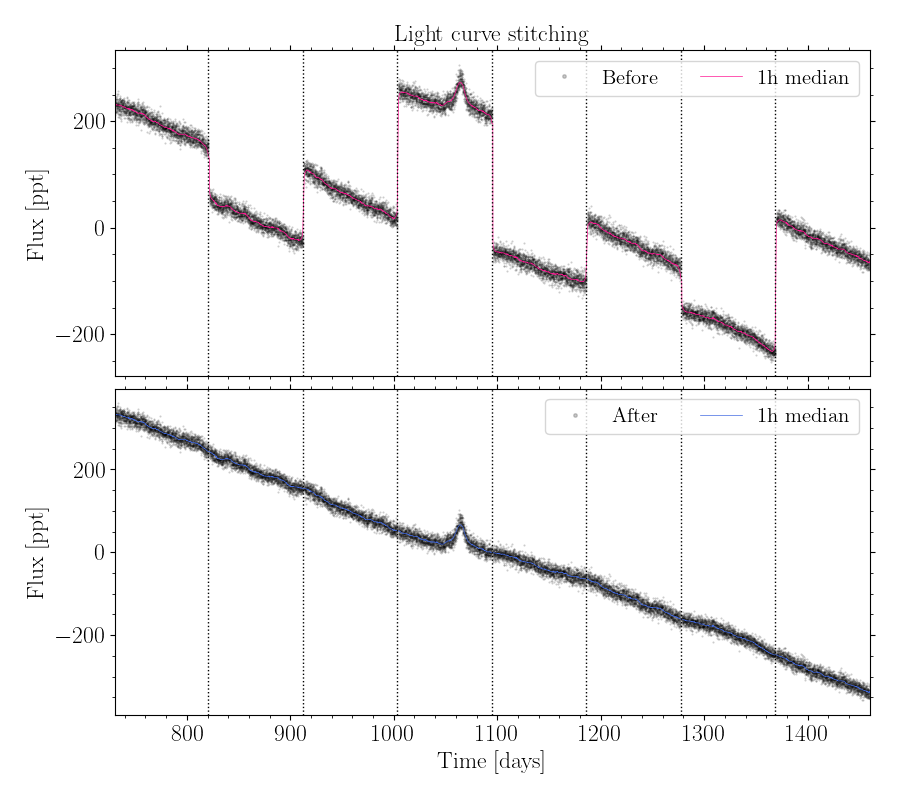

,time,flux,flux_stitch,flux0
0,6.311566e+07,18.182439,18.182439,18.182439
1,6.311926e+07,18.148705,18.148705,18.148705
2,6.312286e+07,18.406102,18.406102,18.406102
3,6.312646e+07,18.237159,18.237159,18.237159
4,6.313006e+07,17.902470,17.902470,17.902470


In [1542]:
# Stitch the light curve
lc = LightCurve(df, mode="multi")
df0 = lc.stitch(method='lowess', segment=10, mask_updates=mask_updates, plot=True)
df0.head()

<IPython.core.display.Javascript object>


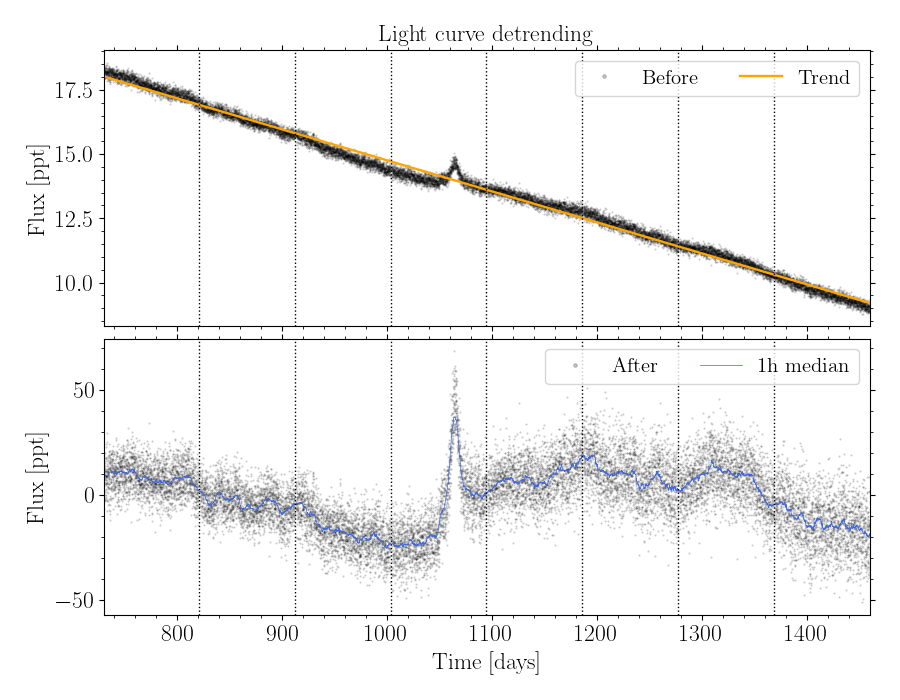

,time,flux,flux_stitch,flux0,flux_trend,flux_detrend
0,6.311566e+07,18.182439,18.182439,18.182439,18.008164,1.009168
1,6.311926e+07,18.148705,18.148705,18.148705,18.007662,1.007420
2,6.312286e+07,18.406102,18.406102,18.406102,18.007159,1.020989
3,6.312646e+07,18.237159,18.237159,18.237159,18.006656,1.012127
4,6.313006e+07,17.902470,17.902470,17.902470,18.006153,0.994545


In [1543]:
# Perform detrending
df1 = lc.detrend(column='flux_stitch', model='poly', poly_degree=1, segments=False, plot=True)
df1.head()

<IPython.core.display.Javascript object>


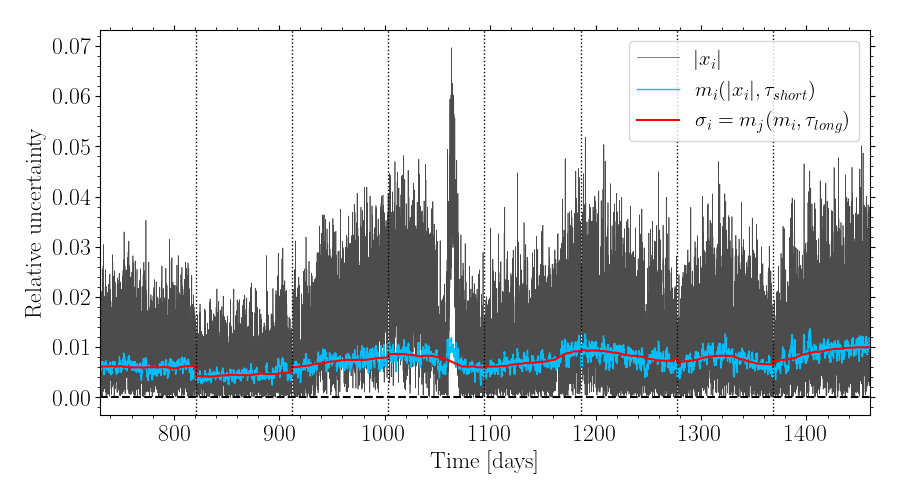

In [1544]:
# Compute flux errors
df = lc.flux_error(column='flux_detrend', plot=True, short_filter=1, long_filter=50, type_filter=np.std)

In [1562]:
dx = df.copy()
#-------------
# corr = np.linspace(1.5, 1.5, df.shape[0]) # P=17.5
# corr = df.flux_trend / df.flux_trend.median()
# dx.flux_detrend = (dx.flux_detrend - 1) * corr + 1
#-------------
dx = dx.reset_index(drop=True)

<IPython.core.display.Javascript object>


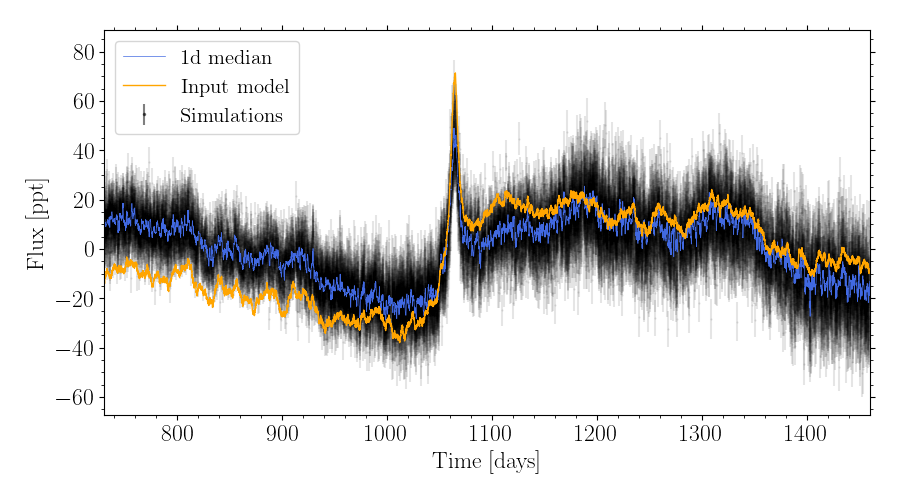

In [1563]:
# Plot camera light curve with errors
time = dx.time / 86400
flux = (dx.flux_detrend - 1) * 1e3
ferr = dx.flux_err * 1e3
fmed = median_filter(flux, 24)
fig1 = plt.figure(figsize=(9,5))
plt.errorbar(time, flux, yerr=ferr, fmt='.k', ms=1, alpha=0.1, zorder=1)
plt.errorbar(time[0], flux[0], yerr=ferr[0], fmt='.k', ms=3, alpha=0.5, zorder=1, label='Simulations')
plt.plot(time, fmed, '-', c='royalblue', lw=0.5, label='1d median')
plt.plot(dv.time, dv.flux, '-', c='orange', lw=1.0, label='Input model')
plt.xlabel('Time [days]')
plt.ylabel('Flux [ppt]')
plt.xlim(time.min(), time.max())
plt.legend(loc='best')
plt.tight_layout();

### Bin data to 1-day cadence

In [1564]:
# Light curve of 1-h cadence
dh = pd.DataFrame()
dh['time'] = dx.time / 86400
dh['flux'] = dx.flux_detrend
dh['flux_err'] = dx.flux_err
dh = dh.reset_index(drop=True)

In [1565]:
# Bin light curve to 1-d cadence
dd = dh.copy()
dd.time *=86400
lc = LightCurve(dd, mode='multi')
dd = lc.bin(binsize=24)
dd.time /= 24
dd = dd.reset_index(drop=True)

<IPython.core.display.Javascript object>


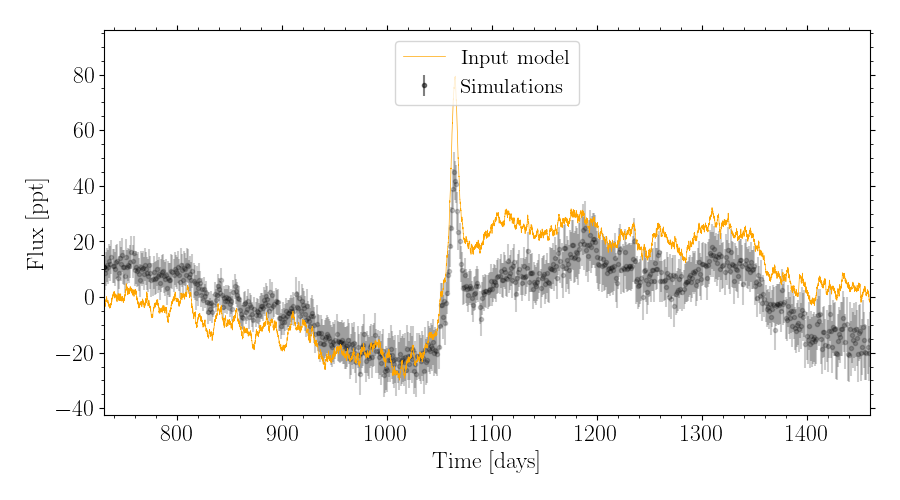

In [1566]:
# Plot light curve with 1-d cadence
time = dd.time
flux = (dd.flux - 1) *  1e3 
ferr = dd.flux_err * 1e3
fmed = median_filter(flux, 5)
fig2 = plt.figure(figsize=(9,5))
plt.errorbar(time, flux, yerr=ferr, fmt='.k', alpha=0.2, zorder=1)
plt.errorbar(time[0], flux[0], yerr=ferr[0], fmt='.k', alpha=0.5, zorder=1, label='Simulations')
# plt.plot(time, fmed, '-', c='royalblue', lw=1, label='5d median')
plt.plot(dv.time, dv.flux+8, '-', c='orange', lw=0.5, label='Input model')
plt.xlabel('Time [days]')
plt.ylabel('Flux [ppt]')
plt.xlim(time.min(), time.max())
plt.legend(loc='upper center')
plt.tight_layout();

### Save light curves

In [1567]:
# Save light curve of 1-h cadence
dh.to_feather(rdir / f'lc_{filename}_1h.ftr')
fig1.savefig(fdir / f'lc_{filename}_1h.png', bbox_inches='tight', dpi=200)

In [1568]:
# Save light curve
dd.to_feather(rdir / f'lc_{filename}_1d.ftr')
fig2.savefig(fdir / f'lc_{filename}.png', bbox_inches='tight', dpi=200)

In [1569]:
sys.exit()

SystemExit: 

---
## Old Data Reduction method
---

### Post-process a single camera light curve

In [ ]:
# Load light curves of a single camera
lcs = LightCurve(odir, mode="multi")
files = lcs.files('hdf5', group=3, camera=1)
cadence = 25
binsize = 600
quarter = 16
nexp_per_quarter = 312113
nexp_per_bin = int(np.ceil(nexp_per_quarter * cadence / binsize))
mask_updates = np.arange(0, (quarter+1)*nexp_per_bin, nexp_per_bin).tolist()

In [ ]:
# Merge all quarters
df0 = pd.DataFrame()
df1 = pd.DataFrame()
for f in files:
    lc = LightCurve(f)
    df1 = lc.bin(binsize=binsize/3600, time_unit='h')
    # Only allow flux measurements above threshold
    if df1.flux.median() < 5:
        df1.flux = np.ones_like(df1.flux.to_numpy) * np.nan
    else:
        df1.flux /= df1.flux.median() 
    # Store data frames
    df1.time *= 3600
    df0 = pd.concat([df0, df1])    
# Deep copy of base flux
df0['flux_base'] = df0.flux

In [ ]:
# Stitch the light curve
lc = LightCurve(df0, mode="multi")
df = lc.stitch(method='lowess', segment=5, mask_updates=mask_updates, plot=True)
df.head()

In [ ]:
# Linear detrend
df = lc.detrend(column='flux_stitch', model='poly', poly_degree=1, segments=False, plot=True)
df.head()

In [ ]:
# Compute flux errors
df = lc.flux_error(column='flux_detrend', plot=True, short_filter=0.5, long_filter=50, type_filter=np.std)

In [ ]:
# Plot camera light curve with errors
time = df.time / 86400
flux = (df.flux_detrend - 1) * 1e3
ferr = df.flux_err * 1e3
fmed = median_filter(flux, 144)
fig = plt.figure(figsize=(9,5))
plt.errorbar(time, flux, yerr=ferr, fmt='.k', alpha=0.05, zorder=1)
plt.plot(time, flux, 'k.', ms=3, alpha=0.1, zorder=1, label='Simulations')
plt.plot(time, fmed, '-', c='royalblue', lw=0.5, label='1d median')
plt.plot(dv.time, dv.flux, '-', c='lime', lw=1.0, label='Input model')
plt.xlabel('Time [days]')
plt.ylabel('Flux [ppt]')
plt.xlim(0, time.max())
plt.legend(loc='best')
plt.tight_layout();

### Post-process to final light curves

In [ ]:
def merge(lcs, cadence=25, binsize=600, tbin=3600, quarters=16, segment=5, poly_degree=2, flux_thres=5):
    # Combine the two datasets while reducing each
    hour = 3600
    nexp_per_quarter = 312113
    nexp_per_bin = int(np.ceil(nexp_per_quarter * cadence / binsize))
    mask_updates = np.arange(0, (quarters + 1)*nexp_per_bin, nexp_per_bin).tolist()
    # Loop over each camera in each group
    dx = pd.DataFrame()
    for g in range(1,5):
        for c in tqdm(range(1,7), bar_format=ut.tqdmBar(), desc=f'Group {g}'):  
            # Merge all quarters
            df0 = pd.DataFrame()
            df1 = pd.DataFrame()
            files = lcs.files('hdf5', group=g, camera=c)
            for f in files:
                lc = LightCurve(f)
                df1 = lc.bin(binsize=binsize/hour, time_unit='h')
                # Only allow flux measurements above threshold [e-/s]
                if df1.flux.median() < flux_thres:
                    df1.flux = np.ones_like(df1.flux.to_numpy) * np.nan
                else:
                    df1.flux /= df1.flux.median() 
                # Store data frames
                df1.time *= hour 
                df0 = pd.concat([df0, df1])
            # Post-process full camera light curve
            lc = LightCurve(df0, mode="multi")
            lc.stitch(method='lowess', segment=segment, mask_updates=mask_updates)
            df = lc.detrend(column='flux_stitch', model='poly', poly_degree=poly_degree, 
                            segments=False, replace=True)
            df = lc.flux_error(short_filter=0.5, long_filter=50)
            dx = pd.concat([dx, df])  
    # Weighted average across equal timings
    dx = dx.reset_index()
    dx = dx.sort_values(by=['time'])
    dx['weight'] = 1 / dx.flux_err**2
    w = lambda x: np.average(x, weights=dx.loc[x.index, "weight"])
    e = lambda x: np.sqrt(1 / np.sum(dx.loc[x.index, "weight"])) 
    dx = dx.groupby(['time']).agg(flux=('flux', w), flux_err=('flux_err', e))
    dx = dx.reset_index()
    # Bin date to final light curve
    if tbin > binsize:
        tdur = dx.time.iloc[-1] - dx.time.iloc[0]
        bins = int(tdur/tbin)
        flux_bin, time_bin, _= binned_statistic(dx.time, dx.flux,     'median', bins)
        flux_err, time_bin, _= binned_statistic(dx.time, dx.flux_err, 'median', bins)
        time_bin = time_bin[:-1] + np.diff(time_bin)[0]/2.
    else:
        time_bin, flux_bin, flux_err = dx.time, dx.flux, dx.flux_err
    flux_med = median_filter(flux_bin, int(24*3600/tbin))
    time_bin /= 86400
    dx = pd.DataFrame({'time':time_bin, 'flux':flux_bin, 'flux_med':flux_med, 'flux_err':flux_err})
    return dx

In [ ]:
# Generate merged final light curve
lcs = LightCurve(odir, mode="multi")
df = merge(lcs, tbin=3600, poly_degree=2, flux_thres=5)

In [ ]:
# Plot reduced light curve
fig = plt.figure(figsize=(9,5))
time = df.time / 86400
flux = (df.flux - 1) * 1e3
ferr = df.flux_err * 1e3
fmed = (df.flux_med - 1) * 1e3
plt.errorbar(time.iloc[0], flux.iloc[0], yerr=ferr.iloc[0], fmt='.k', alpha=0.5, label=r'Simulation', zorder=1)
plt.errorbar(time, flux, yerr=ferr, fmt='.k', alpha=0.01, zorder=1)
plt.plot(time,    flux,    '.', c='k', ms=3, alpha=0.3)
plt.plot(time,    fmed,    '-', c='royalblue', lw=0.5, label='1d median', zorder=2)
plt.plot(dv.time, dv.flux, '-', c='orange', lw=0.7, label='Input model', zorder=3)
plt.xlabel('Time [days]')
plt.ylabel('Flux [ppt]')
plt.xlim(0, time.max())
plt.legend(loc='best')
plt.tight_layout();

In [ ]:
# Save light curve
df.to_feather(sdir / f'finals/lc_{filename}.ftr')
# Save figure
fig.savefig(fdir / f'lc_{filename}.png', bbox_inches='tight', dpi=300)

In [ ]:
# gain_fee = 0.0222 # [ADU/microV]
# B = 1000 * 25 # [ADU/pixel]
# df = lc.data()
# I = df.flux
# I = np.arange(0, 65e3/gain_fee, 1000)
# a = [0.0, -0.0042789409, 0.0000002365]
# O = B + I + a[0] + a[1] * I + a[2] * I**2 

In [ ]:
# plt.figure(figsize=(9,5))
# plt.plot(I, O, '.')